In [1]:
import os
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.manifold import TSNE

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("husl")

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.7 MB/s eta 0:00:28
    --------------------------------------- 2.1/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 3.4/101.7 MB 4.7 MB/s eta 0:00:21
   - -------------------------------------- 4.2/101.7 MB 4.9 MB/s eta 0:00:20
   -- ------------------------------------- 5.5/101.7 MB 5.0 MB/s eta 0:00:20
   -- ------------------------------------- 7.1/101.7 MB 5.3 MB/s eta 0:00:18
   --- ------------------------------------ 8.9/101.7 MB 5.7 MB/s eta 0:00:17
   ---- ----------------------------------- 10.7/101.7 MB 6.1 MB/s eta 0:00:15
   ---- ----------------------------------- 12.6/101.7 MB 6.4 MB/s eta 0:00:14
   ----- ---------------------------------- 14.9/101.7 MB 6.9 MB/s eta 0:00:13
   ------ --------------------------------- 16.8/101.7 MB 7.1 MB/s eta 0:00

In [3]:
# Load already preprocessed data saved from Feature Engineering notebook
df_train = pd.read_csv("./data/data/processed/train_processed_advanced.csv")
df_test  = pd.read_csv("./data/data/processed/test_processed_advanced.csv")

print(f"Train shape : {df_train.shape}")
print(f"Test  shape : {df_test.shape}")
print(f"Class distribution (train):")
print(df_train["attack_class"].value_counts())
df_train.head()

Train shape : (336715, 35)
Test  shape : (22544, 35)
Class distribution (train):
attack_class
4    67343
0    67343
2    67343
1    67343
3    67343
Name: count, dtype: int64


,src_bytes,total_bytes,log_src_bytes,diff_srv_rate,src_bytes_ratio,same_srv_rate,flag_SF,count,dst_host_same_src_port_rate,serror_rate,...,wrong_fragment,rerror_rate,num_compromised,flag_RSTR,srv_diff_host_rate,duration,flag_REJ,log_duration,protocol_type_udp,attack_class
0,1.619565,0.264915,0.425286,0.000000,1.830140,0.000000,0.0,-0.085106,2.833333,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,4
1,0.369565,0.019886,0.210485,2.500000,1.830140,-1.010989,0.0,-0.007092,14.666667,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,1.0,4
2,-0.159420,-0.083807,-0.676858,1.166667,-0.169860,-1.043956,-1.0,0.773050,0.000000,1.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0
3,0.681159,5.871449,0.292385,0.000000,-0.114523,0.000000,0.0,-0.063830,0.500000,0.2,...,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,4
4,0.561594,0.355824,0.265229,0.000000,0.473113,0.000000,0.0,0.113475,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.09,0.0,0.0,0.0,0.0,4


In [4]:
# Separate features and target
X_signal      = df_train.drop(columns=["attack_class"]).values
X_test_signal = df_test.drop(columns=["attack_class"]).values

# Encode labels
le       = LabelEncoder()
y_master = le.fit_transform(df_train["attack_class"])
y_test_l = le.transform(df_test["attack_class"])

print(f"X_signal shape      : {X_signal.shape}")
print(f"X_test_signal shape : {X_test_signal.shape}")
print(f"Classes             : {le.classes_}")

X_signal shape      : (336715, 34)
X_test_signal shape : (22544, 34)
Classes             : [0 1 2 3 4]


In [5]:
#Unsupervised Anamoly Detection
#Isolation Forest
print("Running Isolation Forest...")
iso          = IsolationForest(contamination=0.03, random_state=42, n_jobs=-1)
iso_preds    = iso.fit_predict(X_signal)

# Build a plotting DataFrame with attack class labels
iso_plot_df  = df_train.copy()
iso_plot_df["iso_score"]  = iso_preds
iso_plot_df["is_anomaly"] = iso_plot_df["iso_score"].map({1: 0, -1: 1})

iso_anomaly_count = iso_plot_df["is_anomaly"].sum()
print(f"Isolation Forest — Anomalies detected: {iso_anomaly_count}")

Running Isolation Forest...
Isolation Forest — Anomalies detected: 10102


In [6]:
#Local Outlier Factor
print('Running Local Outlier Factor...')
lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_signal[:5000])

lof_anomaly_count = (lof_labels == -1).sum()
print(f'LOF — Anomalies detected (in 5000 sample): {lof_anomaly_count}')

Running Local Outlier Factor...
LOF — Anomalies detected (in 5000 sample): 250


In [7]:
# One-class SVM
print('Running One-Class SVM...')
oc_svm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
oc_svm.fit(X_signal[:5000])   # Train on sample to learn normal boundary
ocsvm_preds = oc_svm.predict(X_signal[:5000])

ocsvm_anomaly_count = (ocsvm_preds == -1).sum()
print(f'One-Class SVM — Anomalies detected (in 5000 sample): {ocsvm_anomaly_count}')

Running One-Class SVM...
One-Class SVM — Anomalies detected (in 5000 sample): 438


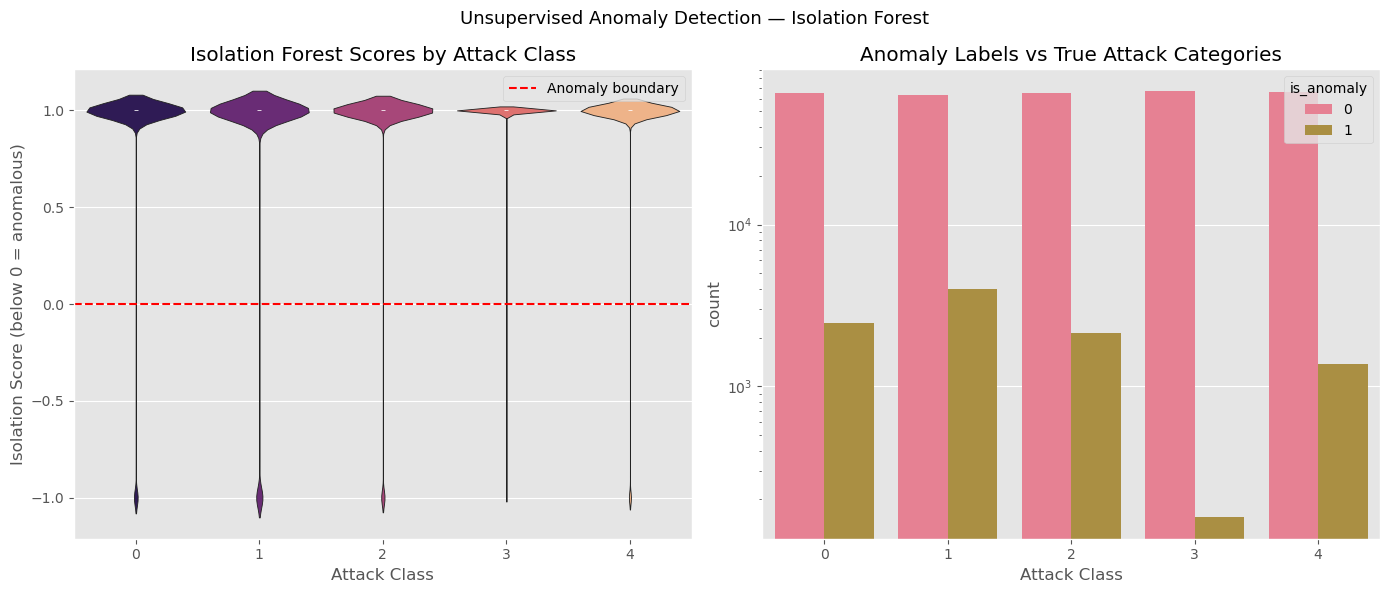

Anomaly Detection Comparison
              Method  Anomalies Detected  Sample Size  Speed               Best For
    Isolation Forest               10102       336715   Fast        Global outliers
Local Outlier Factor                 250         5000   Slow Local/cluster outliers
       One-Class SVM                 438         5000 Medium      Known normal data


In [8]:
# Comparison Visualization 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Isolation Forest scores by attack class
sns.violinplot(x="attack_class", y="iso_score", data=iso_plot_df, palette="magma", ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--", label="Anomaly boundary")
axes[0].set_title("Isolation Forest Scores by Attack Class")
axes[0].set_xlabel("Attack Class")
axes[0].set_ylabel("Isolation Score (below 0 = anomalous)")
axes[0].legend()

# Plot 2: Anomaly flag vs true class
sns.countplot(x="attack_class", hue="is_anomaly", data=iso_plot_df, ax=axes[1])
axes[1].set_title("Anomaly Labels vs True Attack Categories")
axes[1].set_xlabel("Attack Class")
axes[1].set_yscale("log")

plt.suptitle("Unsupervised Anomaly Detection — Isolation Forest", fontsize=13)
plt.tight_layout()
plt.show()

# Summary comparison table
comparison = pd.DataFrame({
    "Method"            : ["Isolation Forest", "Local Outlier Factor", "One-Class SVM"],
    "Anomalies Detected": [iso_anomaly_count, lof_anomaly_count, ocsvm_anomaly_count],
    "Sample Size"       : [len(X_signal), 5000, 5000],
    "Speed"             : ["Fast", "Slow", "Medium"],
    "Best For"          : ["Global outliers", "Local/cluster outliers", "Known normal data"]
})
print("Anomaly Detection Comparison")
print(comparison.to_string(index=False))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_signal, y_master,
    test_size=0.2, random_state=42, stratify=y_master
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test  shape : {X_test.shape}')
print(f'Classes       : {le.classes_}')

X_train shape : (269372, 34)
X_test  shape : (67343, 34)
Classes       : [0 1 2 3 4]


In [10]:
print('Starting Hyperparameter Optimization...')

param_grid = {
    'n_estimators'   : [50, 100],
    'max_depth'      : [10, 20],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=3,
    scoring='f1_macro',
    verbose=1
)

grid.fit(X_train, y_train)

print(f'\nBest Hyperparameters : {grid.best_params_}')
print(f'Best CV F1 Score     : {grid.best_score_:.4f}')

sentinel_brain = grid.best_estimator_

Starting Hyperparameter Optimization...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Hyperparameters : {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 50}
Best CV F1 Score     : 0.9997


In [11]:
# All modeks
models = {
    'Random Forest'     : sentinel_brain,
    'Decision Tree'     : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(
                            n_estimators=50,    # reduced from 100
                            max_depth=3,        # reduced from 5
                            subsample=0.3,      # trains on only 30% of data each tree
                            random_state=42
                          ),
}

# Try XGBoost if installed
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='mlogloss', random_state=42
    )
    print('XGBoost available — included.')
except ImportError:
    print('XGBoost not installed — skipping. Run: pip install xgboost')

results = {}

for name, model in models.items():
    print(f'\nTraining: {name}...')
    model.fit(X_train, y_train)
    y_pred        = model.predict(X_test)
    acc           = accuracy_score(y_test, y_pred)
    f1            = f1_score(y_test, y_pred, average='macro')
    results[name] = {'Accuracy': acc, 'F1 Macro': f1}
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Macro : {f1:.4f}')

XGBoost available — included.

Training: Random Forest...
  Accuracy : 0.9997
  F1 Macro : 0.9997

Training: Decision Tree...
  Accuracy : 0.9976
  F1 Macro : 0.9976

Training: Gradient Boosting...
  Accuracy : 0.9905
  F1 Macro : 0.9905

Training: XGBoost...
  Accuracy : 0.9995
  F1 Macro : 0.9995


In [16]:
# Classification Report
y_pred_best = sentinel_brain.predict(X_test)

# Decode labels back to class names
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred_best])))
class_names    = [['DoS','Probe','R2L','U2R','normal'][i] for i in unique_classes]

print('Classification Report')
print(classification_report(y_test, y_pred_best, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     13469
       Probe       1.00      1.00      1.00     13468
         R2L       1.00      1.00      1.00     13469
         U2R       1.00      1.00      1.00     13469
      normal       1.00      1.00      1.00     13468

    accuracy                           1.00     67343
   macro avg       1.00      1.00      1.00     67343
weighted avg       1.00      1.00      1.00     67343



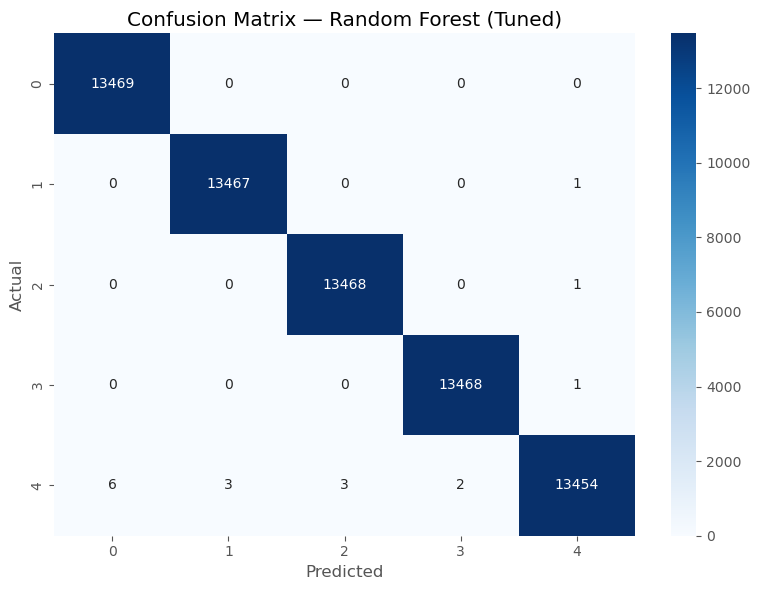

In [17]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Random Forest (Tuned)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

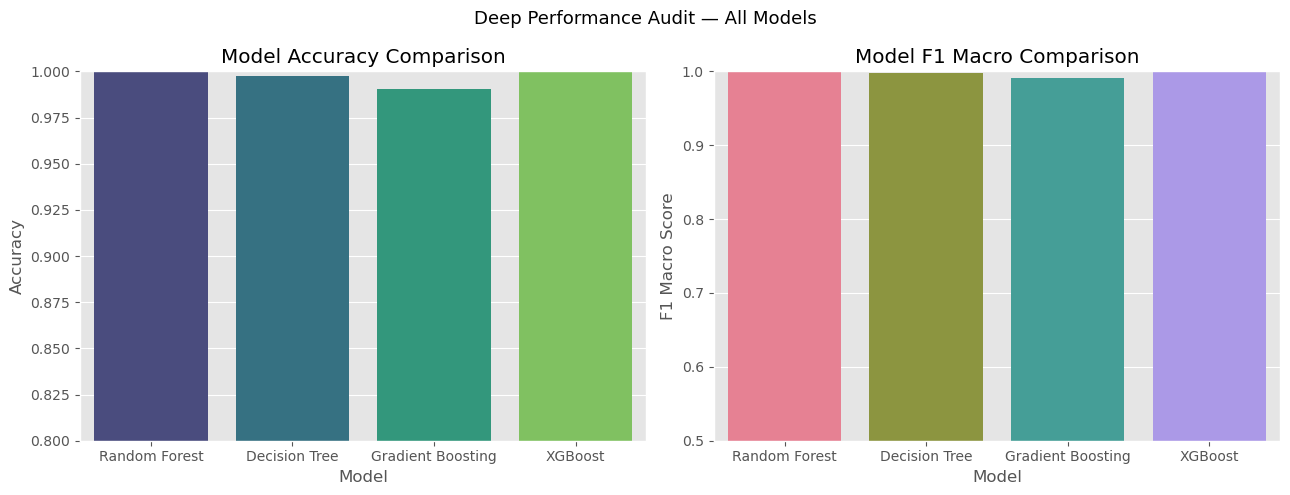


--- Final Model Rankings ---
            Model  Accuracy  F1 Macro
    Random Forest  0.999748  0.999748
          XGBoost  0.999480  0.999480
    Decision Tree  0.997609  0.997607
Gradient Boosting  0.990511  0.990500


In [18]:
#Model Comparison Chart
results_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.barplot(data=results_df, x='Model', y='Accuracy', palette='viridis', ax=axes[0])
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_ylim(0.8, 1.0)
axes[0].set_ylabel('Accuracy')

sns.barplot(data=results_df, x='Model', y='F1 Macro', palette='husl', ax=axes[1])
axes[1].set_title('Model F1 Macro Comparison')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_ylabel('F1 Macro Score')

plt.suptitle('Deep Performance Audit — All Models', fontsize=13)
plt.tight_layout()
plt.show()

print('\n--- Final Model Rankings ---')
print(results_df.sort_values('F1 Macro', ascending=False).to_string(index=False))

In [20]:
# Cross Validation Score — Best Model
skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(sentinel_brain, X_signal, y_master,
                             cv=skf, scoring='f1_macro', n_jobs=-1)

print(f'Cross Validation F1 Scores : {cv_scores.round(4)}')
print(f'Mean CV F1                 : {cv_scores.mean():.4f}')
print(f'Std  CV F1                 : {cv_scores.std():.4f}')

Cross Validation F1 Scores : [0.9996 0.9997 0.9996 0.9997 0.9997]
Mean CV F1                 : 0.9997
Std  CV F1                 : 0.0001
